In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from collections import namedtuple

from scipy.signal import find_peaks

## Model

Model has many parameters. To keep them in order,
we can use namedtuple or dictionary. Here, we use
namedtuple

In [2]:
# Create a named tuple with its fields (attributes) —- our parameters -- listed in the second input argument
# Values are assigned to each parameter later in the code
params = namedtuple('params', ['C',
                               'g_L', 'g_Na', 'g_K',
                               'E_L', 'E_Na', 'E_K',
                               'V_half_m', 'V_half_n',
                               'k_m', 'k_n',
                               'tau',
                               'Istim_func'
                              ])

params.__doc__

'params(C, g_L, g_Na, g_K, E_L, E_Na, E_K, V_half_m, V_half_n, k_m, k_n, tau, Istim_func)'

In [3]:
def model(t, state, model_parameters):

    """ Reduced HH model - Eqs. 2.14-2.17 of the lecture notes.

    Parameters
    ----------

        - t : scalar
            Time point at which to evaluate
            dv/dt and dn/dt.

        - state : tuple with 2 elements
            Values of `v` and `n` at which to evaluate
            dv/dt and dn/dt.

        - model_parameters : collections.namedtuple
            Values of model parameters are attributes
            of `model_parameters`.

    Returns
    -------

        - tuple with 2 elements
            dv/dt and dn/dt

    """

    C = model_parameters.C
    g_L = model_parameters.g_L
    g_Na = model_parameters.g_Na
    g_K = model_parameters.g_K
    E_L = model_parameters.E_L
    E_Na = model_parameters.E_Na
    E_K = model_parameters.E_K
    V_half_m = model_parameters.V_half_m
    V_half_n = model_parameters.V_half_n
    k_m = model_parameters.k_m
    k_n = model_parameters.k_n
    tau = model_parameters.tau
    Istim_func = model_parameters.Istim_func # Callable. Must receive t as an argument and return stim current

    v = state[0]
    n = state[1]

    m_inf = 1 / (1 + np.exp((V_half_m - v) / k_m) )
    n_inf = 1 / (1 + np.exp((V_half_n - v) / k_n) )

    I_leak = g_L*(v - E_L)
    I_na = g_Na*m_inf*(v - E_Na)
    I_k = g_K*n*(v - E_K)

    dvdt = (Istim_func(t) - I_leak - I_na - I_k) / C
    dndt = (n_inf - n) / tau

    return (dvdt, dndt)

## Parameters

In [4]:
# Parameters as in Table 2.3 of the lecture notes

BaseParams = params(
C = 1,
g_L = 8,
E_L = -78,          #for low-threshold I_K for test and Hopf
g_Na = 20,
E_Na = 60,
g_K = 10,
E_K = -90,
V_half_m = -20,
k_m = 15,
tau = 1,           # for test and for Hopf and for SN
V_half_n = -45,    # for low-threshold I_K used for test and for Hopf
k_n = 5,
Istim_func = 0
)

In [5]:
# Set time limits, time-step, t_start
t_span = [0, 400]

dt = 0.01 # sec

t_start = 0 # Olga: We are only interested in the system's dyncamis in the steady state,
               # so we skip the initial part of the solution, where the system is far
               # from the steady state.
               # To see how the system evolves to the steady state, set t_start = 0

t_eval = np.arange(t_start, t_span[1], dt)

In [6]:
# Set stimulating current as a sinusoid
stim_freq = 0.016
stim_magn = 40

p = BaseParams._replace(Istim_func = lambda t_val : stim_magn * 0.5*(1 + np.sin( 2*np.pi*stim_freq * t_val )))

## Task 3 Forced bursting - Hopf biffurcation

In [7]:
state_initial = (-60, 0.2)
solution = solve_ivp(model, t_span, state_initial, args=[p,], t_eval=t_eval)

### Figure

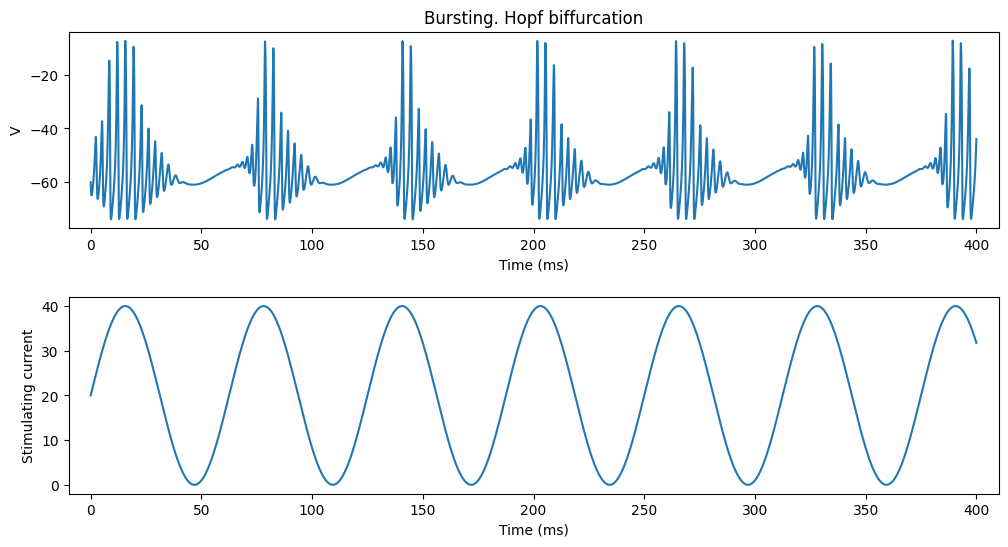

In [8]:
f, axs = plt.subplots(2, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=0.35)

axs[0].plot(solution.t, solution.y[0])
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('V')
axs[0].set_title('Bursting. Hopf biffurcation')
# axs[0].set_ylim([-100, 0])

axs[1].plot(t_eval, p.Istim_func(t_eval))
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('Stimulating current')

for ax in axs:
    ax.set_xlim(t_span[0]-10, t_span[1]+10)

## Task 3 Forced bursting - Saddle-node biffurcation

In [ ]:
p = BaseParams._replace(E_L = -80, V_half_n = -25, Istim_func = lambda t_val : stim_magn * 0.5*(1 + np.sin( 2*np.pi*stim_freq * t_val )))

In [ ]:
solution = solve_ivp(model, t_span, state_initial, args=[p,], t_eval=t_eval)

### Figure

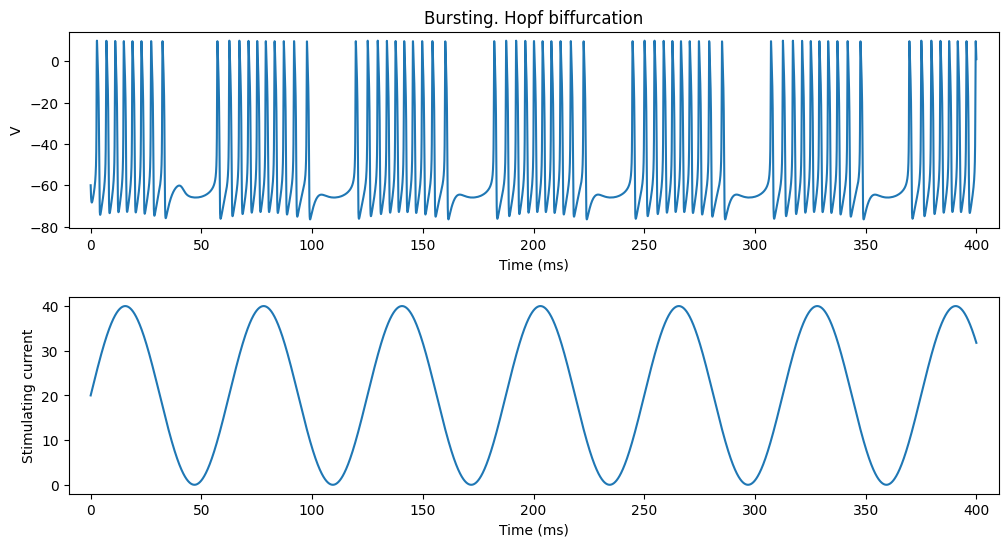

In [ ]:
f, axs = plt.subplots(2, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=0.35)

axs[0].plot(solution.t, solution.y[0])
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('V')
axs[0].set_title('Bursting. Hopf biffurcation')

axs[1].plot(t_eval, p.Istim_func(t_eval))
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('Stimulating current')

for ax in axs:
    ax.set_xlim(t_span[0]-10, t_span[1]+10)